# Evaluación 2
## Programación Científica 2026-1

**Estudiante:** Laura Gómez Angulo

**Cédula:** 1017929190

In [174]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

datos = np.load("/datos_9190.npz")

X = datos["X"]
y = datos["y"]
t = datos["t"]
meta = datos["meta"]

In [175]:
print(X.shape)
print(X[0].shape)

(45, 256)
(256,)


In [176]:
def capa_fourier(t, K=30):
    filas = []

    for k in range(1, K + 1):
        filas.append(np.sin(2 * np.pi * k * t))
        filas.append(np.cos(2 * np.pi * k * t))

    W1 = np.array(filas)

    return W1

In [177]:
t = np.linspace(0, 1, 256) # Define t as a time vector consistent with signal length
W1 = capa_fourier(t)

print(W1.shape)

(60, 256)


In [178]:
x = X[0]

print(x.shape)

(256,)


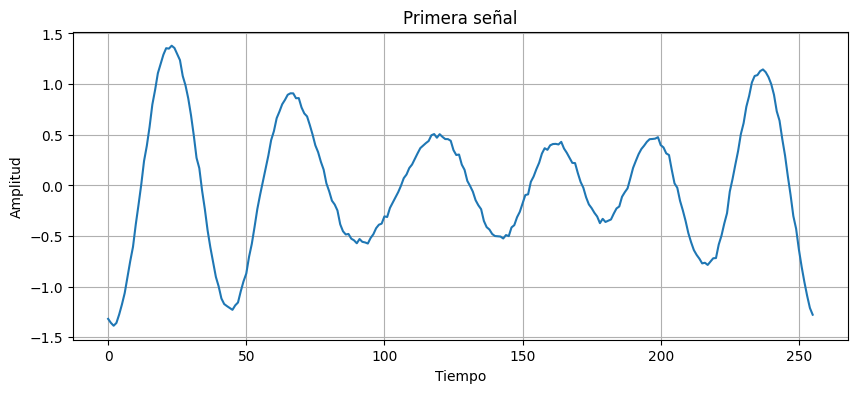

In [179]:
plt.figure(figsize=(10,4))

plt.plot(x)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)


plt.title("Primera señal")

plt.show()

In [180]:
coef = W1 @ x

print(coef.shape)

(60,)


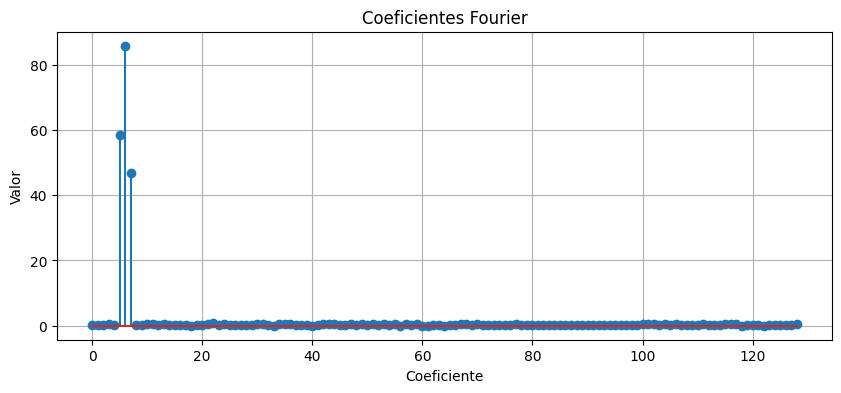

In [221]:
plt.figure(figsize=(10,4))

plt.stem(coef)

plt.xlabel("Coeficiente")
plt.ylabel("Valor")
plt.grid(True)

plt.title("Coeficientes Fourier")

plt.show()

In [182]:
def red(params, x):

    W1, W2 = params

    h = jnp.tanh(W1 @ x)

    x_hat = W2 @ h

    return x_hat

In [183]:
def init_fourier():

    W1 = jnp.array(capa_fourier(t, K=35)) # Explicitly pass K=35 to ensure correct dimensions

    key = jax.random.PRNGKey(0)

    W2 = 0.01 * jax.random.normal(
        key,
        (256,70) # Changed from (256, 100) to (256, 70) to match K=35
    )

    return [W1,W2] # Ensured W2 matches K=35

In [184]:
def init_random():

    key = jax.random.PRNGKey(1)

    k1,k2 = jax.random.split(key)

    W1 = 0.01 * jax.random.normal(
        k1,
        (60,256)
    )

    W2 = 0.01 * jax.random.normal(
        k2,
        (256,60)
    )

    return [W1,W2]

In [185]:
def loss(params, X):

    errores = []

    for x in X:

        x_hat = red(params,x)

        errores.append(
            jnp.mean((x_hat-x)**2)
        )

    return jnp.mean(
        jnp.array(errores)
    )

In [186]:
params_fourier = init_fourier()

print(
    loss(params_fourier,X)
) # Re-initializing params_fourier to pick up latest function definitions

0.70349216


In [187]:
print(X.shape)
print(y.shape)


(45, 256)
(45,)


In [188]:
print(np.unique(y))


[0 1 2]


In [189]:
print("Régimen 0:", np.sum(y == 0))
print("Régimen 1:", np.sum(y == 1))
print("Régimen 2:", np.sum(y == 2))


Régimen 0: 15
Régimen 1: 15
Régimen 2: 15


In [190]:
X0 = X[y == 0]
X1 = X[y == 1]
X2 = X[y == 2]

print(X0.shape)
print(X1.shape)
print(X2.shape)


(15, 256)
(15, 256)
(15, 256)


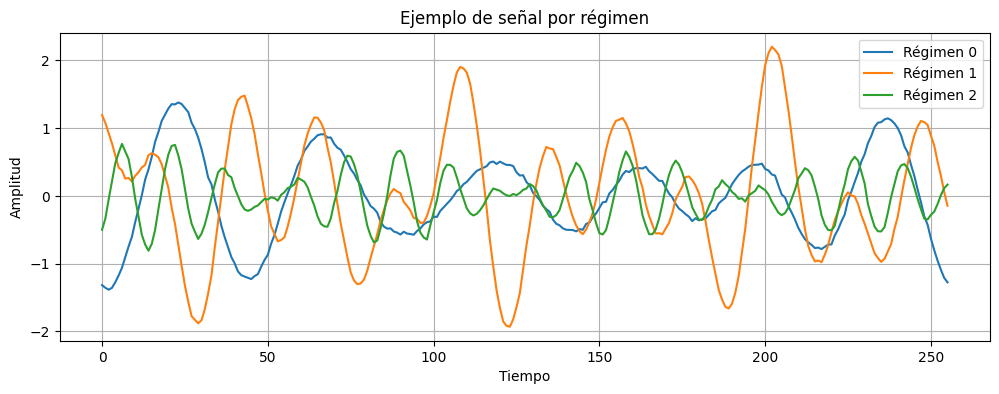

In [191]:
plt.figure(figsize=(12,4))

plt.plot(X0[0], label="Régimen 0")
plt.plot(X1[0], label="Régimen 1")
plt.plot(X2[0], label="Régimen 2")

plt.legend()
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Ejemplo de señal por régimen")
plt.grid(True)

plt.show()

In [192]:
grad_loss = jax.grad(loss)

@jax.jit
def update(params, X, lr=0.02):
    grads = grad_loss(params, X)

    nuevos = [
        p - lr * g
        for p, g in zip(params, grads)
    ]

    return nuevos

In [193]:
def train(params, X,
          epochs=2000,
          lr=0.02):

    historial = []

    for i in range(epochs):

        params = update(
            params,
            X,
            lr
        )

        if i % 10 == 0:

            L = loss(
                params,
                X
            )

            historial.append(
                float(L)
            )

    return params, historial

In [194]:
def error_relativo(x, x_hat):

    return (
        np.linalg.norm(
            np.array(x_hat) - np.array(x)
        )
        /
        np.linalg.norm(
            np.array(x)
        )
    )

In [195]:
def iteracion_umbral(hist, umbral=0.1):

    for i, valor in enumerate(hist):

        if valor < umbral:
            return i * 10

    return None

In [196]:
params_fourier_0 = init_fourier()

params_fourier_0, hist_fourier_0 = train(
    params_fourier_0,
    X0,
    epochs=2000
)

In [197]:
params_random_0 = init_random()

params_random_0, hist_random_0 = train(
    params_random_0,
    X0,
    epochs=2000
)

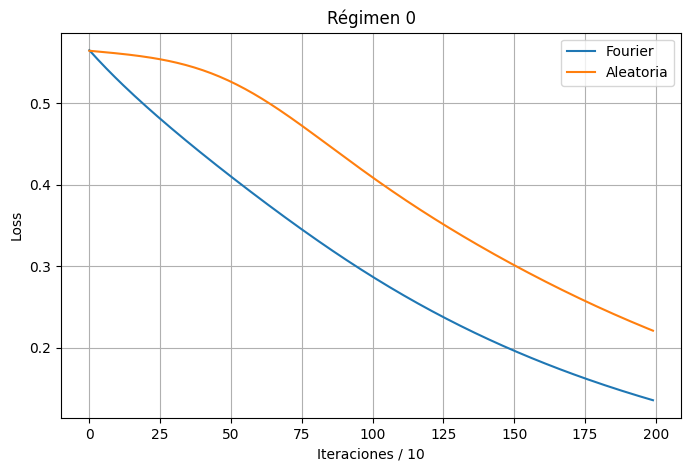

In [198]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_0,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_0,
    label="Aleatoria"
)

plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title(
    "Régimen 0"
)

plt.legend()

plt.show()

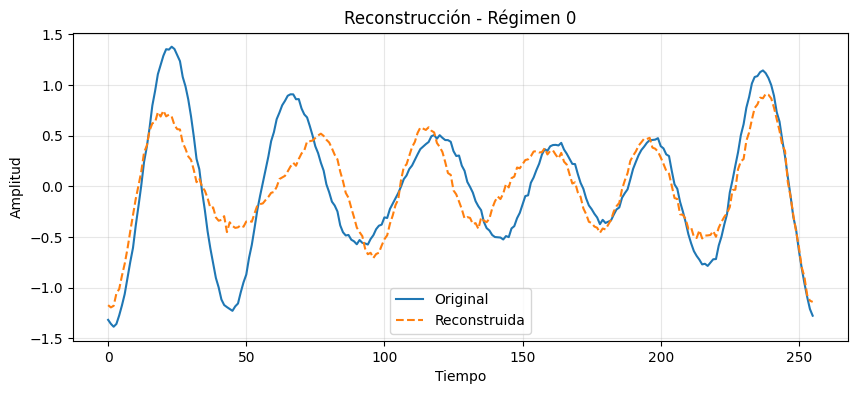

In [199]:
x0 = X0[0]

x0_hat = red(
    params_fourier_0,
    x0
)

plt.figure(figsize=(10,4))

plt.plot(
    x0,
    label="Original"
)

plt.plot(
    np.array(x0_hat),
    "--",
    label="Reconstruida"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción - Régimen 0"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")

plt.legend()

plt.show()

In [200]:
print("RÉGIMEN 0")

print(
    "Fourier:",
    iteracion_umbral(hist_fourier_0)
)

print(
    "Aleatoria:",
    iteracion_umbral(hist_random_0)
)

RÉGIMEN 0
Fourier: None
Aleatoria: None


In [201]:
err0 = error_relativo(
    x0,
    x0_hat
)

print(
    f"Error relativo régimen 0: {err0:.4f}"
)

Error relativo régimen 0: 0.5314


In [202]:
params_fourier_1 = init_fourier()

params_fourier_1, hist_fourier_1 = train(
    params=params_fourier_1,
    X=X1,
    epochs=2000
)

In [203]:
params_random_1 = init_random()

params_random_1, hist_random_1 = train(
    params_random_1,
    X1,
    epochs=2000
)

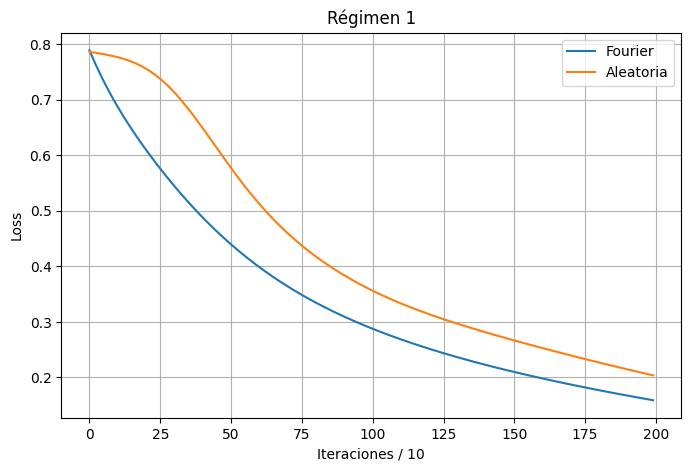

In [204]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_1,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_1,
    label="Aleatoria"
)

plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title("Régimen 1")

plt.legend()

plt.show()

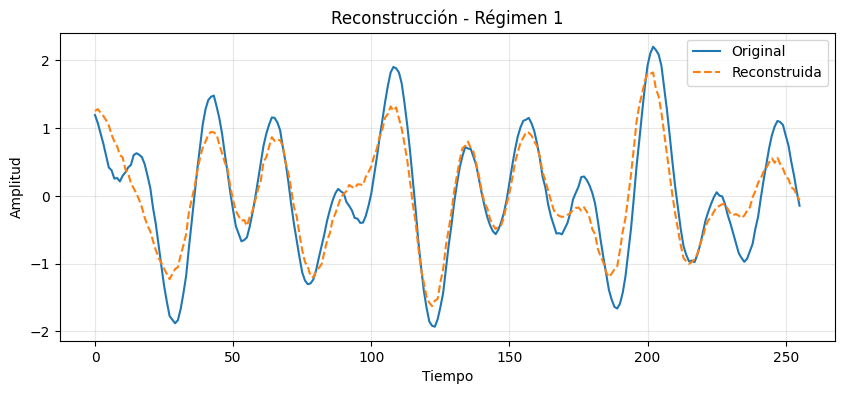

In [205]:
x1 = X1[0]

x1_hat = red(
    params_fourier_1,
    x1
)

plt.figure(figsize=(10,4))

plt.plot(
    x1,
    label="Original"
)

plt.plot(
    np.array(x1_hat),
    "--",
    label="Reconstruida"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción - Régimen 1"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")

plt.legend()

plt.show()

In [206]:
err1 = error_relativo(
    x1,
    x1_hat
)

print(
    f"Error relativo régimen 1: {err1:.4f}"
)

Error relativo régimen 1: 0.4180


In [207]:
print("RÉGIMEN 1")

print(
    "Fourier:",
    iteracion_umbral(hist_fourier_1)
)

print(
    "Aleatoria:",
    iteracion_umbral(hist_random_1)
)

RÉGIMEN 1
Fourier: None
Aleatoria: None


In [208]:
params_fourier_2 = init_fourier()

params_fourier_2, hist_fourier_2 = train(
    params_fourier_2,
    X2,
    epochs=2000
)

In [209]:
params_random_2 = init_random()

params_random_2, hist_random_2 = train(
    params_random_2,
    X2,
    epochs=2000
)

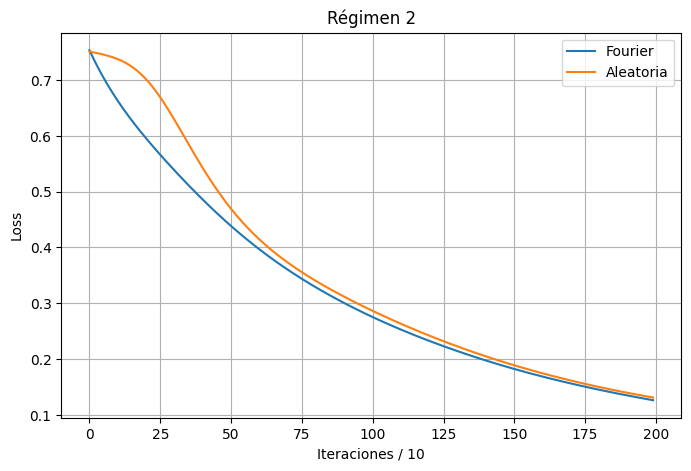

In [210]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_2,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_2,
    label="Aleatoria"
)

plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title("Régimen 2")

plt.legend()

plt.show()

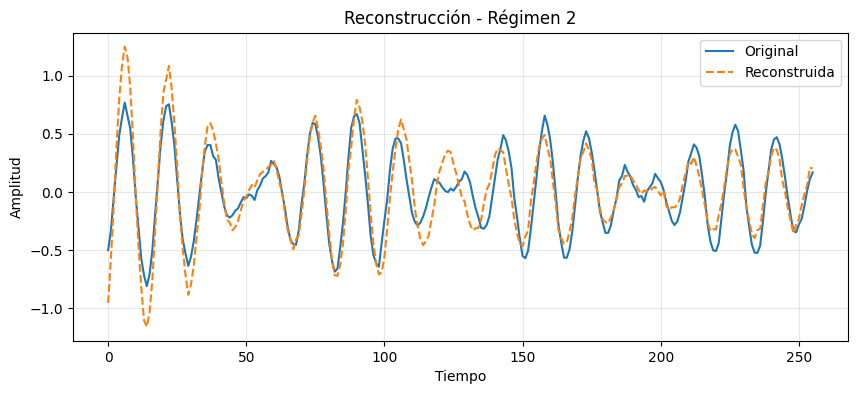

In [211]:
x2 = X2[0]

x2_hat = red(
    params_fourier_2,
    x2
)

plt.figure(figsize=(10,4))

plt.plot(
    x2,
    label="Original"
)

plt.plot(
    np.array(x2_hat),
    "--",
    label="Reconstruida"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción - Régimen 2"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")

plt.legend()

plt.show()

In [212]:
err2 = error_relativo(
    x2,
    x2_hat
)

print(
    f"Error relativo régimen 2: {err2:.4f}"
)

Error relativo régimen 2: 0.4827


In [213]:
print("RÉGIMEN 2")

print(
    "Fourier:",
    iteracion_umbral(hist_fourier_2)
)

print(
    "Aleatoria:",
    iteracion_umbral(hist_random_2)
)

RÉGIMEN 2
Fourier: None
Aleatoria: None


In [214]:
print("Errores relativos")
print("------------------")

print(
    f"Régimen 0 : {err0:.4f}"
)

print(
    f"Régimen 1 : {err1:.4f}"
)

print(
    f"Régimen 2 : {err2:.4f}"
)

Errores relativos
------------------
Régimen 0 : 0.5314
Régimen 1 : 0.4180
Régimen 2 : 0.4827


In [215]:
print("VELOCIDAD DE CONVERGENCIA")
print("-------------------------")

print(
    f"Reg 0 -> Fourier: {iteracion_umbral(hist_fourier_0)}"
)

print(
    f"Reg 0 -> Aleatoria: {iteracion_umbral(hist_random_0)}"
)

print()

print(
    f"Reg 1 -> Fourier: {iteracion_umbral(hist_fourier_1)}"
)

print(
    f"Reg 1 -> Aleatoria: {iteracion_umbral(hist_random_1)}"
)

print()

print(
    f"Reg 2 -> Fourier: {iteracion_umbral(hist_fourier_2)}"
)

print(
    f"Reg 2 -> Aleatoria: {iteracion_umbral(hist_random_2)}"
)

VELOCIDAD DE CONVERGENCIA
-------------------------
Reg 0 -> Fourier: None
Reg 0 -> Aleatoria: None

Reg 1 -> Fourier: None
Reg 1 -> Aleatoria: None

Reg 2 -> Fourier: None
Reg 2 -> Aleatoria: None


In [216]:
x = X0[0]

coef = np.abs(
    np.fft.rfft(x)
)

energia = coef**2

energia_total = energia.sum()

energia_ordenada = np.sort(
    energia
)[::-1]

energia_acumulada = np.cumsum(
    energia_ordenada
)

fraccion = (
    energia_acumulada
    /
    energia_total
)

In [217]:
n_coef = np.argmax(
    fraccion >= 0.85
) + 1

print(
    f"Coeficientes necesarios: {n_coef}"
)

print(
    f"Fracción de energía: {fraccion[n_coef-1]:.3f}"
)

Coeficientes necesarios: 3
Fracción de energía: 0.999


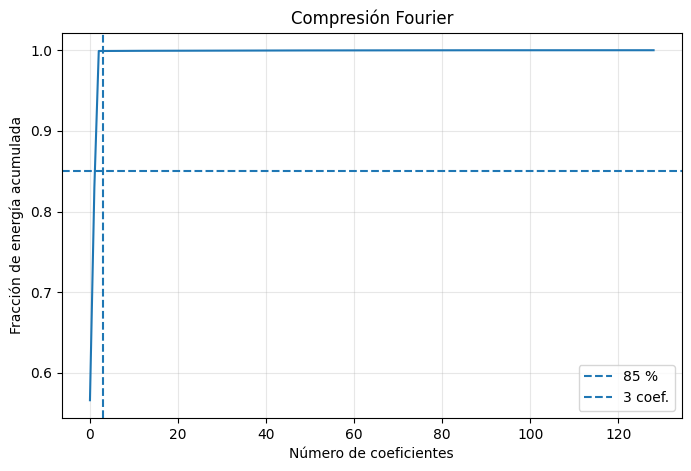

In [218]:
plt.figure(figsize=(8,5))

plt.plot(
    fraccion
)

plt.axhline(
    0.85,
    linestyle="--",
    label="85 %"
)

plt.axvline(
    n_coef,
    linestyle="--",
    label=f"{n_coef} coef."
)

plt.grid(alpha=0.3)

plt.xlabel(
    "Número de coeficientes"
)

plt.ylabel(
    "Fracción de energía acumulada"
)

plt.title(
    "Compresión Fourier"
)

plt.legend()

plt.show()

In [219]:
errores = []

coef_fft = np.fft.rfft(x)

for k in range(1, len(coef_fft)+1):

    indices = np.argsort(
        np.abs(coef_fft)
    )[::-1]

    nuevo = np.zeros_like(
        coef_fft
    )

    nuevo[
        indices[:k]
    ] = coef_fft[
        indices[:k]
    ]

    x_rec = np.fft.irfft(
        nuevo,
        n=len(x)
    )

    err = np.linalg.norm(
        x - x_rec
    ) / np.linalg.norm(x)

    errores.append(err)

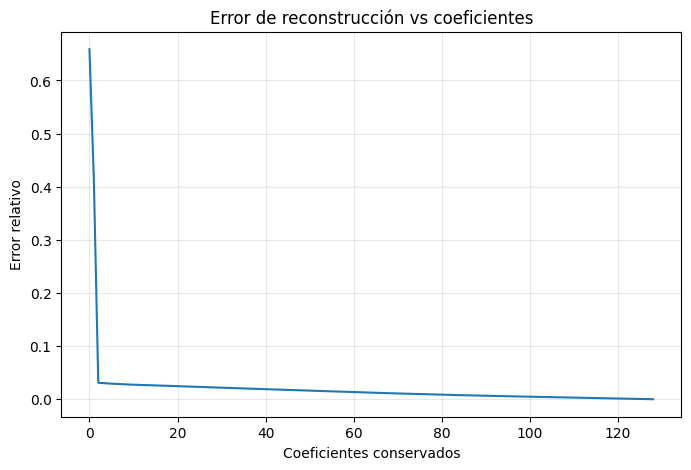

In [220]:
plt.figure(figsize=(8,5))

plt.plot(
    errores
)

plt.grid(alpha=0.3)

plt.xlabel(
    "Coeficientes conservados"
)

plt.ylabel(
    "Error relativo"
)

plt.title(
    "Error de reconstrucción vs coeficientes"
)

plt.show()